In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
import sys
print(sys.executable)


c:\Users\Bijaya\miniconda3\envs\viz311\python.exe


In [6]:
# Load CSV
df = pd.read_csv("./ball_camera_coordinates_02.csv")

x = df['X']
y = df['Y']
z = df['Z']

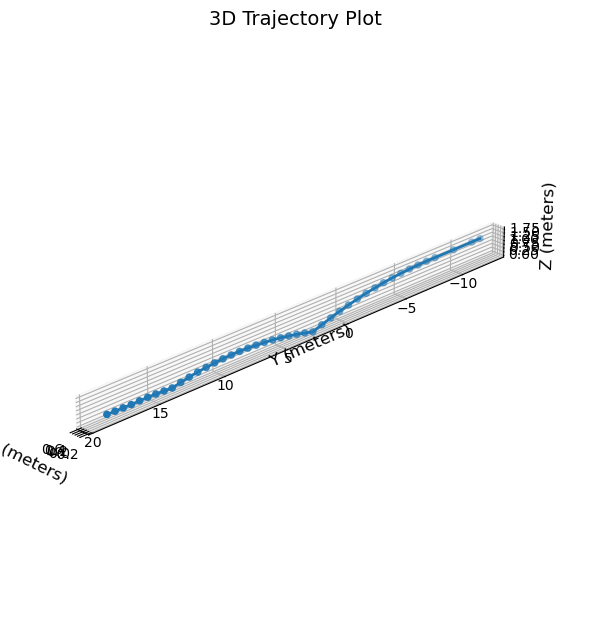

In [13]:
# Create figure
fig = plt.figure(figsize=(6, 40))
ax = fig.add_subplot(111, projection='3d')

ax.set_box_aspect([
    x.max() - x.min(),
    y.max() - y.min(),
    z.max() - z.min()
])

# Plot
ax.plot(x, y, z, linewidth=2)
ax.scatter(x, y, z, s=20)

# Labels
ax.set_xlabel("X (meters)", fontsize=12)
ax.set_ylabel("Y (meters)", fontsize=12)
ax.set_zlabel("Z (meters)", fontsize=12)

# Title
ax.set_title("3D Trajectory Plot", fontsize=14, pad=15)

# View angle (important for clarity)
ax.view_init(elev=25, azim=135)

# Grid
ax.grid(True)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# # Load data: frame, Z_raw, Z_kalman
# data = np.loadtxt('trajectory_z.dat', comments='%')
# frames = data[:, 0]
# z_raw = data[:, 1]
# z_kalman = data[:, 2]

In [115]:
# Load z_kalman.csv
z_kalman_df = pd.read_csv("z_kalman_final.csv")

# Display the first few rows of the dataframe
print(z_kalman_df.head())
frames = z_kalman_df['Frame']
z_raw = z_kalman_df['Z_raw']/1000
z_kalman = z_kalman_df['Z_kalman']/1000

   Frame        Z_raw     Z_kalman
0      0  1896.703421  1896.701382
1      1  2602.008314  2257.019547
2      3  3085.096287  2668.897413
3      4  3509.812459  3015.023864
4      5  4176.021758  3534.816529


In [119]:
z_kalman_c = pd.read_csv('smoothed_z_kalman.csv')
frames = z_kalman_c['Frame']
z_raw = z_kalman_c['Z_raw']/1000
z_kalman = z_kalman_c['Z_kalman']/1000

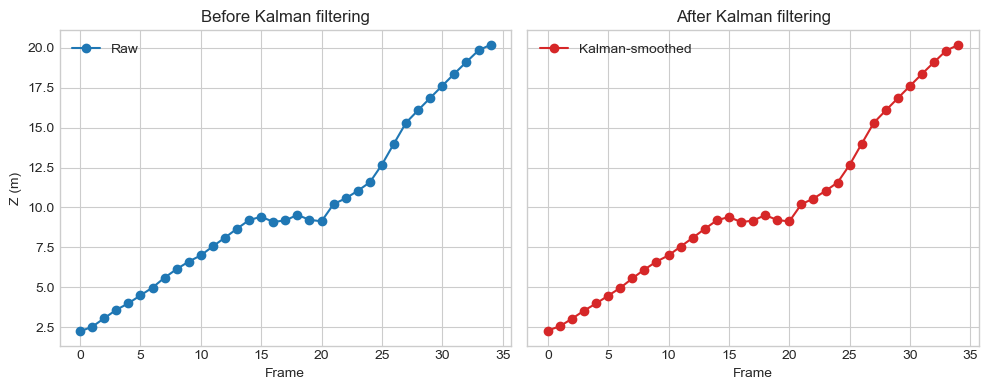

In [120]:
plt.style.use('seaborn-v0_8-whitegrid')  # optional style

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# --- Left: raw (before Kalman) ---
ax = axes[0]
ax.plot(frames, z_raw, marker='o', linestyle='-', color='tab:blue', label='Raw')
ax.set_title('Before Kalman filtering')
ax.set_xlabel('Frame')
ax.set_ylabel('Z (m)')
ax.legend()
ax.grid(True)

# --- Right: Kalman-smoothed (after) ---
ax = axes[1]
ax.plot(frames, z_kalman, marker='o', linestyle='-', color='tab:red', label='Kalman-smoothed')
ax.set_title('After Kalman filtering')
ax.set_xlabel('Frame')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

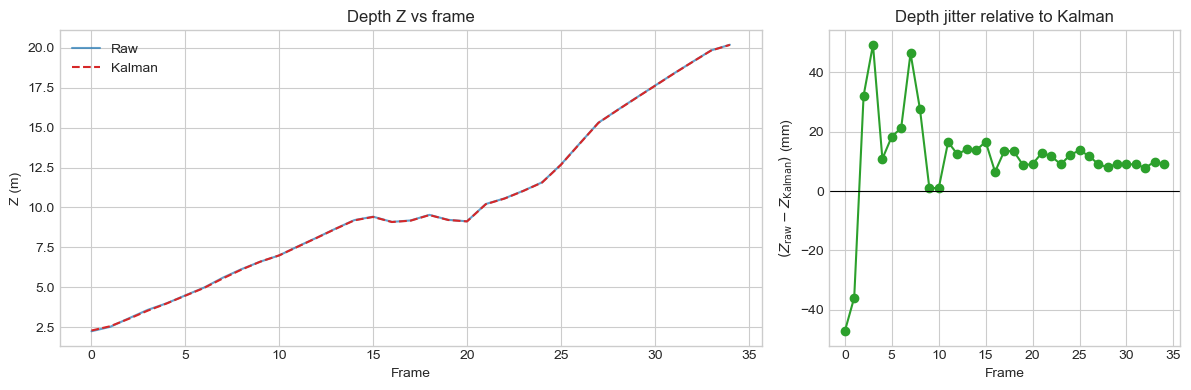

In [121]:
dz = z_raw - z_kalman  # deviation in Z

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={'width_ratios': [2, 1]}  # left 2x wider than right
)

# Absolute Z (overlay)
ax = axes[0]
ax.plot(frames, z_raw, color='tab:blue', alpha=0.7, label='Raw')
ax.plot(frames, z_kalman, color='tab:red', linestyle='--', label='Kalman')
ax.set_xlabel('Frame')
ax.set_ylabel('Z (m)')
ax.set_title('Depth Z vs frame')
ax.legend()
ax.grid(True)

# Difference (jitter)
ax = axes[1]
ax.plot(frames, dz * 1000.0, marker='o', linestyle='-', color='tab:green')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel(r'$(Z_{\mathrm{raw}} - Z_{\mathrm{Kalman}})$ (mm)')
ax.set_title('Depth jitter relative to Kalman')
ax.grid(True)

plt.tight_layout()
plt.savefig("kalman_depth_comparison.png", dpi=500, bbox_inches="tight")
plt.show()

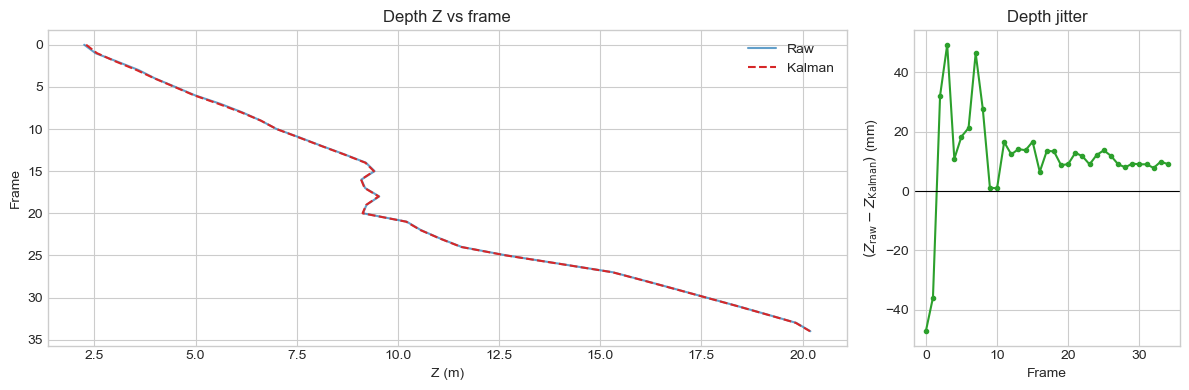

In [122]:
# assuming frames, z_raw, z_kalman already loaded
dz = z_raw - z_kalman  # deviation in Z

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={'width_ratios': [3, 1]}  # left 3x wider than right
)

# --- Left: absolute Z (overlay, main plot) ---
ax = axes[0]
ax.plot(z_raw, frames, color='tab:blue', alpha=0.7, label='Raw')
ax.plot(z_kalman, frames, color='tab:red', linestyle='--', label='Kalman')
ax.set_xlabel('Z (m)')
ax.set_ylabel('Frame')
ax.set_title('Depth Z vs frame')
ax.invert_yaxis()  # optional, to keep time increasing downward like image rows
ax.legend()
ax.grid(True)

# --- Right: jitter (difference) ---
ax = axes[1]
ax.plot(frames, dz * 1000.0, marker='o', markersize=3,
        linestyle='-', color='tab:green')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel(r'$(Z_{\mathrm{raw}} - Z_{\mathrm{Kalman}})$ (mm)')
ax.set_title('Depth jitter')
ax.grid(True)

plt.tight_layout()
plt.show()


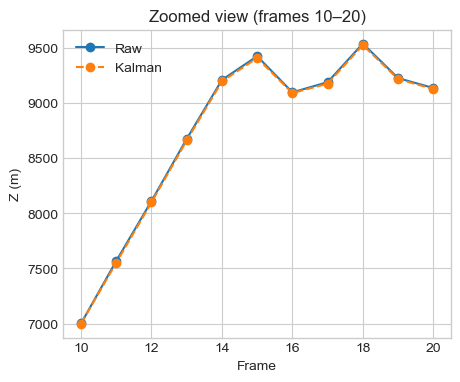

In [125]:
mask = (frames >= 10) & (frames <= 20)

plt.figure(figsize=(5, 4))
plt.plot(frames[mask], z_raw[mask]*1000, 'o-', label='Raw')
plt.plot(frames[mask], z_kalman[mask]*1000, 'o--', label='Kalman')
plt.xlabel('Frame')
plt.ylabel('Z (m)')
plt.title('Zoomed view (frames 10–20)')
plt.legend()
plt.grid(True)
plt.show()